#### 그래프 실행
- RunnableConfig
    - recursion_limit: 최대 노드 실행 개수 지정 (순환 로직에 빠지지 않기 위함)
    - thread_id: 그래프 실행 아이디 기록, 추후 추적하기 위한 목적으로 활용됨 (multi-turn 대화할 때, 이 id 별로 따로 대화내용 저장)
    
- 상태(State)로 시작
    - 여기서 "question"에 질문만 입력하고 상태를 첫 번째 노드에 전달
- invoke(상태, config) 전달하여 실행

In [1]:
from graphs.graph import build_graph
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import HumanMessage

graph = build_graph()
config = RunnableConfig(
    configurable={
        "thread_id": "research-001",
    }
)

inputs = {"messages": [HumanMessage(content="Domain adaptation in clinical drug")]}

for event in graph.stream(inputs, config=config, subgraphs=True):
    print(event)

c:\Users\Kisti\miniconda3\envs\agent\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


LangSmith 추적을 시작합니다.
[프로젝트명]
GAPAGO
(('query_subgraph:b4640380-e2b2-6307-10d6-52bddd34a93d', 'query_analysis:ec2a35cc-2b46-89d1-2177-3acfcc32dcbd'), {'model': {'messages': [AIMessage(content='{\n  "scores": {\n    "domain_clarity": {\n      "score": 0.3,\n      "reason": "The topic mentions \'clinical drug\' but is incomplete and does not specify whether this refers to clinical drug discovery, clinical drug response prediction, clinical drug trials, or clinical drug safety.",\n      "clarifying_question": "Which specific aspect of \'clinical drug\' are you focusing on (e.g., drug discovery, drug response prediction, clinical trials, adverse event detection)?"\n    },\n    "task_clarity": {\n      "score": 0.2,\n      "reason": "The intended research task is unclear—domain adaptation could be applied to prediction, classification, translation, feature alignment, or model generalization.",\n      "clarifying_question": "What task do you want domain adaptation to address (e.g., predictive

In [2]:
from langchain_core.messages import HumanMessage

graph.update_state(
    config,
    {
        "messages": [
            HumanMessage(
                content="I am interested in domain adaptation for clinical drug datasets, focusing on prediction tasks using adversarial and discrepancy-based methods, especially recent work after 2020."
            )
        ]
    },
)

for i, event in enumerate(graph.stream(inputs, config, subgraphs=True)):
    path, update = event

    print(f"\n===== EVENT {i} =====")
    print("PATH:", " -> ".join(path))

    for node, values in update.items():

        if node == "__interrupt__":
            print("\n*** INTERRUPT ***")
            continue

        print(f"\n--- NODE: {node} ---")

        msgs = values.get("messages", [])
        for msg in msgs:
            print(f"\n[{type(msg).__name__}] name={getattr(msg,'name',None)}")
            msg.pretty_print()


===== EVENT 0 =====
PATH: query_subgraph:e0805abc-10c0-db25-358a-2bfc12a1bea7 -> query_analysis:527c5de6-1673-7c7a-9e7d-a438df416f90

--- NODE: model ---

[AIMessage] name=None
================================== Ai Message ==================================

{
  "scores": {
    "domain_clarity": {
      "score": 0.9,
      "reason": "The domain is clearly clinical drug datasets and domain adaptation in machine learning. This is specific and well grounded.",
      "clarifying_question": null
    },
    "task_clarity": {
      "score": 0.8,
      "reason": "The user states interest in prediction tasks, but the exact type of prediction (e.g., efficacy prediction, ADR prediction, dosage prediction) is not specified.",
      "clarifying_question": "What specific prediction task within clinical drug datasets are you focusing on (e.g., adverse drug reactions, drug response, treatment outcomes)?"
    },
    "methodology_clarity": {
      "score": 0.95,
      "reason": "Adversarial and discrep

In [3]:
output2 = graph.invoke(None, config)
print(output2["messages"][-1].content)

Here is the **final consolidated report** synthesizing all stages of the multi‑agent pipeline.

FINAL REPORT: Domain Adaptation for Clinical Drug Prediction

1) RELATED PAPERS (Title / Year / One-line Relevance)

• AdaDiag: Adversarial Domain Adaptation of Diagnostic Prediction with Clinical Event Sequences (2022)  
  Relevance: Uses adversarial UDA on EHR data across institutions, illustrating real‑world clinical dataset shift issues.

• PANCDR: Domain Adaptation for Cancer Drug Response Using an Adversarial Network (2021)  
  Relevance: Directly addresses preclinical→clinical domain adaptation for drug response prediction using adversarial methods.

• Evaluation of Domain Generalization and Adaptation for Temporal Dataset Shift in Clinical Medicine (2021)  
  Relevance: Benchmarks adversarial and discrepancy DA methods on clinical prediction tasks under temporal shift.

• MADAN: Multi-source Adversarial Domain Aggregation Network (2020)  
  Relevance: Methodologically relevant advers

In [6]:
from utils.vis_graph import visualize_graph

visualize_graph(graph, xray=True)

그래프 시각화 실패 (추가 종속성 필요): Found duplicate subgraph 'model' -- this likely means that you're reusing a subgraph node with the same name. Please adjust your graph to have subgraph nodes with unique names.
ASCII로 그래프 표시:
                       +-----------+                                  
                       | __start__ |                                  
                       +-----------+                                  
                              *                                       
                              *                                       
                              *                                       
                       +-----------+                                  
                       | __start__ |....                              
                       +-----------+    ......                        
                        **                    .......                 
                      **                             ......           
   

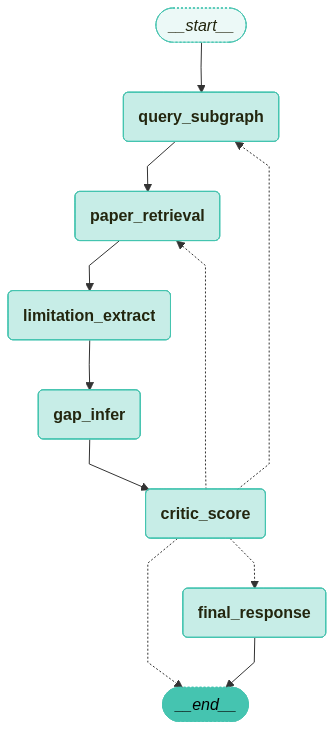

In [7]:
visualize_graph(graph, xray=False)

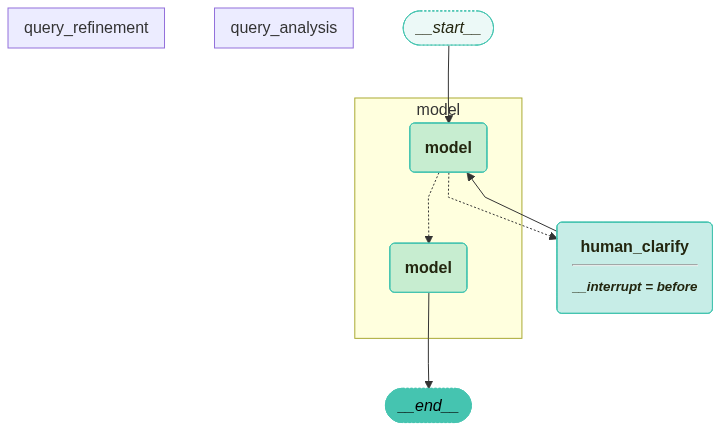

In [8]:
from graphs.query_subgraph import build_subgraph

sub = build_subgraph()
visualize_graph(sub, xray=True)